# Sales Forcasting


In [ ]:
# df_temp = df.copy()


# # Check lengths of lists in each row
# lengths = df_temp[['Lineitem name', 'Lineitem price', 'Lineitem compare at price', 
#                'Lineitem sku', 'Lineitem sku_made', 'Lineitem quantity', 
#                'Lineitem discount']].applymap(len)

# mismatched_rows = lengths[lengths.nunique(axis=1) > 1]

# print("Rows with mismatched lengths:")
# print(mismatched_rows)

# df_temp = df_temp[~df_temp.index.isin(mismatched_rows.index)]

# # Explode the DataFrame if lengths match
# df_exploded = df_temp.explode(['Lineitem name', 'Lineitem price', 
#                            'Lineitem compare at price', 'Lineitem sku_made', 
#                            'Lineitem sku', 'Lineitem quantity', 
#                            'Lineitem discount'])

# # # Reset index if needed
# df_exploded.reset_index(drop=True, inplace=True)

# # # Display the exploded DataFrame
# df_exploded


# # Example: Typecasting columns from object to float64
# columns_to_cast = ['Lineitem price', 'Lineitem compare at price','Lineitem sku_made','Lineitem discount','Lineitem quantity']  # Replace with your column names

# for col in columns_to_cast:
#     df_exploded[col] = pd.to_numeric(df_exploded[col], errors='coerce')  # Converts to float64, invalid parsing will be set as NaN

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report



In [125]:
temp_sales = pd.read_csv('daily_sales_data.csv')
print(temp_sales.isnull().sum())
temp_sales.dropna(inplace=True)
temp_sales = temp_sales[temp_sales['Subtotal'] <= 300000]
temp_sales.set_index('Created at', inplace=True)
temp_sales.index = pd.to_datetime(temp_sales.index)

Created at                        0
Total                             0
Subtotal                          0
item_count                        0
total_7d_avg                      6
total_30d_avg                    29
items_7d_avg                      6
total_7d_std                      6
total_prev_day                    1
total_prev_week                   7
total_prev_month                 30
total_same_day_last_week          7
items_same_day_last_week          7
total_growth_1d                   1
total_growth_1w                   7
quarter                           0
day_of_year                       0
week_of_year                      0
week_sin                          0
week_cos                          0
year_sin                          0
year_cos                          0
total_discount                    0
discount_ratio                    0
avg_shipping_cost                 0
avg_items_per_order               0
days_to_next_shopping_holiday     0
next_shopping_holiday       

In [126]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report


In [127]:
features = [
    "total_prev_day", "total_prev_week", "total_same_day_last_week", "total_7d_avg",
    "total_30d_avg", "total_7d_std", "total_growth_1d", "total_growth_1w",
    "day_of_year", "week_sin", "week_cos", "discount_ratio", "avg_shipping_cost", "avg_items_per_order"
]
X = temp_sales[features]
X.dropna(inplace=True)
X.set_index(temp_sales.index ,inplace=True)
X.index = pd.to_datetime(X.index)
print(X.shape)
y = temp_sales['Subtotal']

X_train = X[X.index < '2025-02-01']
X_test = X[X.index >= '2025-02-01']
y_train = y[X.index < '2025-02-01']
y_test = y[X.index >= '2025-02-01']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(870, 14)


## Liner Reg

R-squared train: 0.8574263943145437
root mean_squared_error train: 15948.219118125442
R-squared test: 0.8596142946370902
root Mean Squared Error: 8137.356741092877


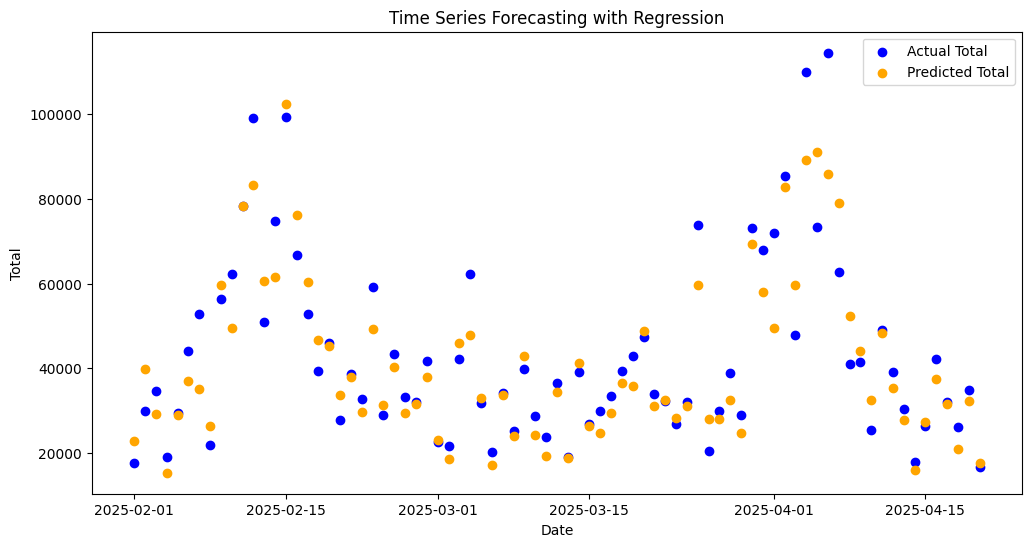

In [128]:

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_train_pred = model.predict(X_train_scaled)

print("R-squared train:", r2_score(y_train, y_train_pred))
print("root mean_squared_error train:",np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("R-squared test:", r2_score(y_test, y_pred))
print("root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))


# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(y_test.index, y_test, label='Actual Total', color='blue')
plt.scatter(y_test.index, y_pred, label='Predicted Total', color='orange')
plt.title('Time Series Forecasting with Regression')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend()
plt.show()

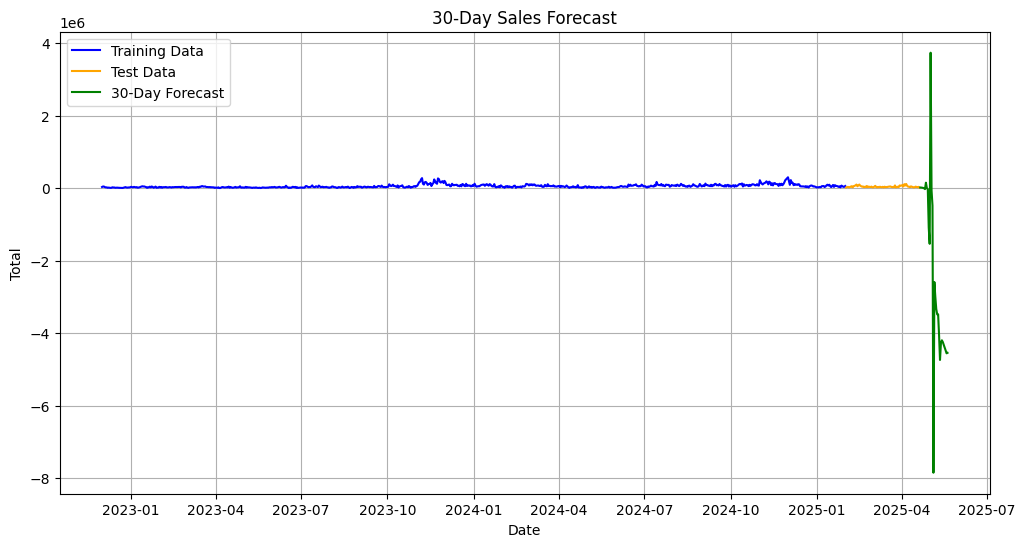

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Initialize the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prepare for forecasting
last_data = X.iloc[-1].copy()  
future_predictions = []
forecast_dates = []

# Forecast for the next 30 days
for i in range(1, 31):
    # Forecast date
    forecast_date = X.index[-1] + pd.Timedelta(days=i)
    forecast_dates.append(forecast_date)

    # Update lag features
    last_data['total_prev_day'] = future_predictions[-1] if future_predictions else last_data['total_prev_day']
    last_data['total_prev_week'] = future_predictions[-7] if len(future_predictions) >= 7 else last_data['total_prev_week']
    last_data['total_same_day_last_week'] = future_predictions[-7] if len(future_predictions) >= 7 else last_data['total_same_day_last_week']

    # Update rolling statistics
    if future_predictions:
        last_7d = future_predictions[-7:] if len(future_predictions) >= 7 else future_predictions
        last_data['total_7d_avg'] = np.mean(last_7d)
        last_data['items_7d_avg'] = np.mean(last_7d) 
        last_data['total_7d_std'] = np.std(last_7d)

    # Update growth features
    if len(future_predictions) >= 1:
        last_data['total_growth_1d'] = ((future_predictions[-1] - future_predictions[-2]) / future_predictions[-2]) if len(future_predictions) >= 2 and future_predictions[-2] != 0 else 0
    if len(future_predictions) >= 7:
        last_data['total_growth_1w'] = ((future_predictions[-1] - future_predictions[-7]) / future_predictions[-7]) if len(future_predictions) >= 7 and future_predictions[-7] != 0 else 0

    # Update time-based features
    last_data['day_of_year'] = forecast_date.day_of_year
    last_data['week_of_year'] = forecast_date.isocalendar()[1]
    last_data['week_sin'] = np.sin(2 * np.pi * last_data['week_of_year'] / 52)
    last_data['week_cos'] = np.cos(2 * np.pi * last_data['week_of_year'] / 52)
    last_data['year_sin'] = np.sin(2 * np.pi * forecast_date.day_of_year / 365.25)
    last_data['year_cos'] = np.cos(2 * np.pi * forecast_date.day_of_year / 365.25)

    # Business-specific features (constant or dynamic as needed)
    last_data['discount_ratio'] = last_data['discount_ratio']
    last_data['avg_shipping_cost'] = last_data['avg_shipping_cost']
    last_data['avg_items_per_order'] = last_data['avg_items_per_order']

    # Prepare data for prediction
    last_data = last_data[features]  # Ensure correct feature order
    last_data_scaled = scaler.transform([last_data.values])

    # Make prediction
    next_prediction = model.predict(last_data_scaled)[0]
    future_predictions.append(next_prediction)

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'date': forecast_dates,
    'forecast': future_predictions
})
forecast_df.set_index('date', inplace=True)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data', color='blue')
plt.plot(y_test.index, y_test, label='Test Data', color='orange')
plt.plot(forecast_df.index, forecast_df['forecast'], label='30-Day Forecast', color='green')
plt.title('30-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend()
plt.grid()
plt.show()

## XGBOOST

R-squared train XGBoost: 0.9992943409368183
mean_squared_error train XGBoost: 1121.9928499505418
XGBoost R-squared: 0.9660260400183531
XGBoost Mean Squared Error: 4003.0867073352515


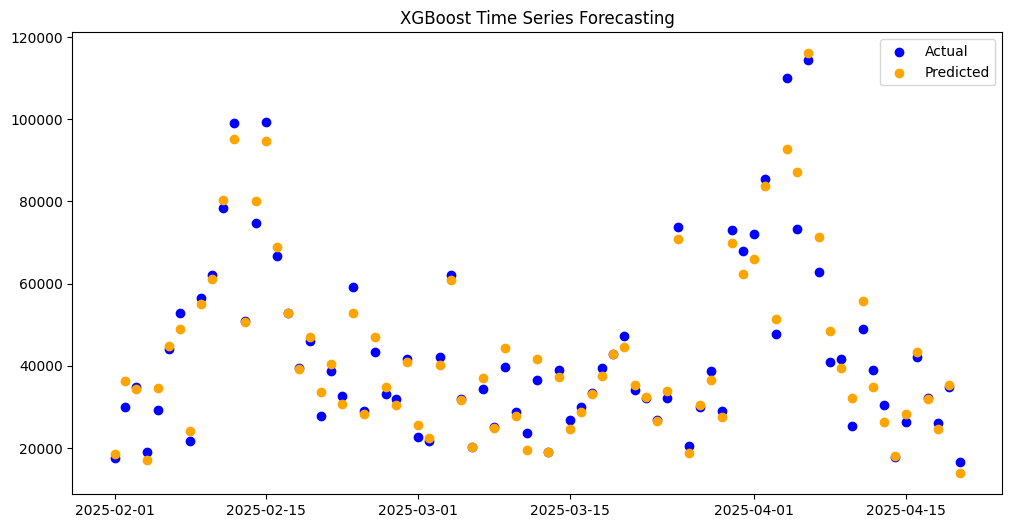

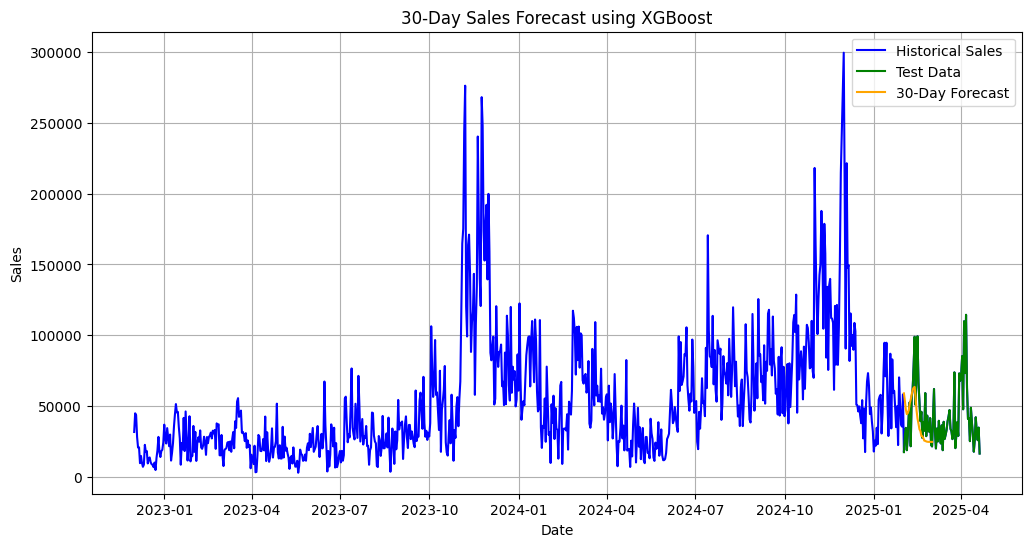

In [130]:
model = XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train_scaled, y_train)

# Predictions on the test set
y_pred_xgb = model.predict(X_test_scaled)
y_train_pred_xgb = model.predict(X_train_scaled)

# Evaluation
print("R-squared train XGBoost:", r2_score(y_train, y_train_pred_xgb))
print("mean_squared_error train XGBoost:", np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)))
print("XGBoost R-squared:", r2_score(y_test, y_pred_xgb))
print("XGBoost Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

# Forecast the next 30 days
last_data = X_train.iloc[-1].copy()
future_predictions = []
forecast_dates = []

for i in range(1, 31):  # Forecast for the next 30 days
    forecast_date = X_train.index[-1] + pd.Timedelta(days=i)
    forecast_dates.append(forecast_date)

    # Update lag features using previous predictions
    last_data["total_prev_day"] = future_predictions[-1] if future_predictions else last_data["total_prev_day"]
    last_data["total_prev_week"] = future_predictions[-7] if len(future_predictions) >= 7 else last_data["total_prev_week"]
    last_data["total_same_day_last_week"] = future_predictions[-7] if len(future_predictions) >= 7 else last_data["total_same_day_last_week"]

    # Update rolling statistics
    if future_predictions:
        last_7d = future_predictions[-7:] if len(future_predictions) >= 7 else future_predictions
        last_30d = future_predictions[-30:] if len(future_predictions) >= 30 else future_predictions
        last_data["total_7d_avg"] = np.mean(last_7d)
        last_data["total_30d_avg"] = np.mean(last_30d)
        last_data["total_7d_std"] = np.std(last_7d)

    # Update growth features
    if len(future_predictions) >= 1:
        last_data["total_growth_1d"] = ((future_predictions[-1] - future_predictions[-2]) / future_predictions[-2]) if len(future_predictions) >= 2 else 0
    if len(future_predictions) >= 7:
        last_data["total_growth_1w"] = ((future_predictions[-1] - future_predictions[-7]) / future_predictions[-7]) if len(future_predictions) >= 7 else 0

    # Update time-based features
    last_data["day_of_year"] = forecast_date.day_of_year
    last_data["week_of_year"] = forecast_date.isocalendar()[1]
    last_data["week_sin"] = np.sin(2 * np.pi * last_data["week_of_year"] / 52)
    last_data["week_cos"] = np.cos(2 * np.pi * last_data["week_of_year"] / 52)

    # Business-specific features (assumed constant; adjust if needed)
    last_data["discount_ratio"] = last_data["discount_ratio"]
    last_data["avg_shipping_cost"] = last_data["avg_shipping_cost"]
    last_data["avg_items_per_order"] = last_data["avg_items_per_order"]

    # Ensure the feature order matches the training feature order
    last_data = last_data[features]
    last_data_scaled = scaler.transform([last_data.values])
    # Make prediction
    next_prediction = model.predict(last_data_scaled)[0]
    future_predictions.append(next_prediction)

# Create a DataFrame for forecasted values
forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "forecast": future_predictions
})
forecast_df.set_index("date", inplace=True)
forecast_df.index = pd.to_datetime(forecast_df.index)


plt.figure(figsize=(12, 6))
plt.scatter(y_test.index,y_test, label='Actual',marker='o', color='blue')
plt.scatter(y_test.index,y_pred_xgb, label='Predicted',marker='o', color='orange')
plt.legend()
plt.title('XGBoost Time Series Forecasting')
plt.show()
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(temp_sales.index, temp_sales["Subtotal"], label="Historical Sales", color="blue")
plt.plot(y_test.index, y_test, label="Test Data", color="green")
plt.plot(forecast_df.index, forecast_df["forecast"], label="30-Day Forecast", color="orange")
plt.title("30-Day Sales Forecast using XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()


## Prophet model

00:28:59 - cmdstanpy - INFO - Chain [1] start processing
00:29:00 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-12-01,18247.361571,49168.686757,115975.311994,18247.361571,18247.361571,63656.852695,63656.852695,63656.852695,-1913.809599,-1913.809599,-1913.809599,65570.662294,65570.662294,65570.662294,0.0,0.0,0.0,81904.214266
1,2022-12-02,18357.799405,49904.606604,118305.194404,18357.799405,18357.799405,64541.247046,64541.247046,64541.247046,2941.736911,2941.736911,2941.736911,61599.510135,61599.510135,61599.510135,0.0,0.0,0.0,82899.046451
2,2022-12-03,18468.237239,41626.452656,107082.445645,18468.237239,18468.237239,56131.721969,56131.721969,56131.721969,-1340.094998,-1340.094998,-1340.094998,57471.816967,57471.816967,57471.816967,0.0,0.0,0.0,74599.959208
3,2022-12-04,18578.675073,41134.380930,105122.306601,18578.675073,18578.675073,54821.418272,54821.418272,54821.418272,1600.686306,1600.686306,1600.686306,53220.731965,53220.731965,53220.731965,0.0,0.0,0.0,73400.093345
4,2022-12-05,18689.112907,32196.871673,99005.980860,18689.112907,18689.112907,47749.948707,47749.948707,47749.948707,-1130.477799,-1130.477799,-1130.477799,48880.426506,48880.426506,48880.426506,0.0,0.0,0.0,66439.061614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868,2025-04-19,48682.711624,-6677.352989,56869.411044,48682.711624,48682.711624,-24848.811400,-24848.811400,-24848.811400,-1340.094998,-1340.094998,-1340.094998,-23508.716401,-23508.716401,-23508.716401,0.0,0.0,0.0,23833.900225
869,2025-04-20,48575.059079,-5370.499614,61555.603004,48575.059079,48575.059079,-22421.568020,-22421.568020,-22421.568020,1600.686306,1600.686306,1600.686306,-24022.254327,-24022.254327,-24022.254327,0.0,0.0,0.0,26153.491058
870,2025-04-27,47821.491260,-9646.189048,56837.624126,47818.352964,47822.543870,-23844.239676,-23844.239676,-23844.239676,1600.686306,1600.686306,1600.686306,-25444.925982,-25444.925982,-25444.925982,0.0,0.0,0.0,23977.251584
871,2025-05-04,47067.923441,-10167.983237,57953.955930,47032.263073,47098.676285,-25315.226535,-25315.226535,-25315.226535,1600.686306,1600.686306,1600.686306,-26915.912842,-26915.912842,-26915.912842,0.0,0.0,0.0,21752.696906


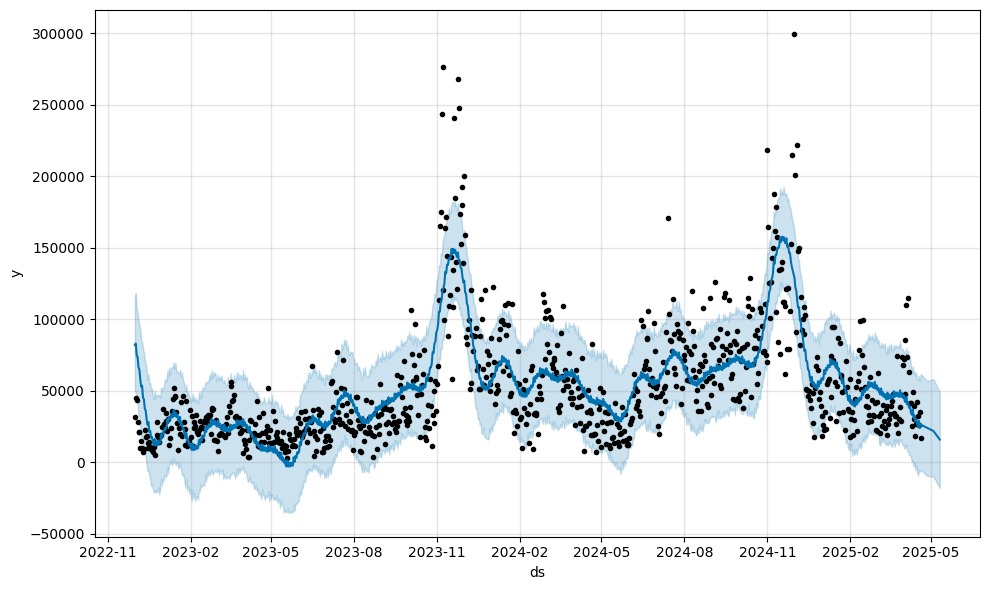

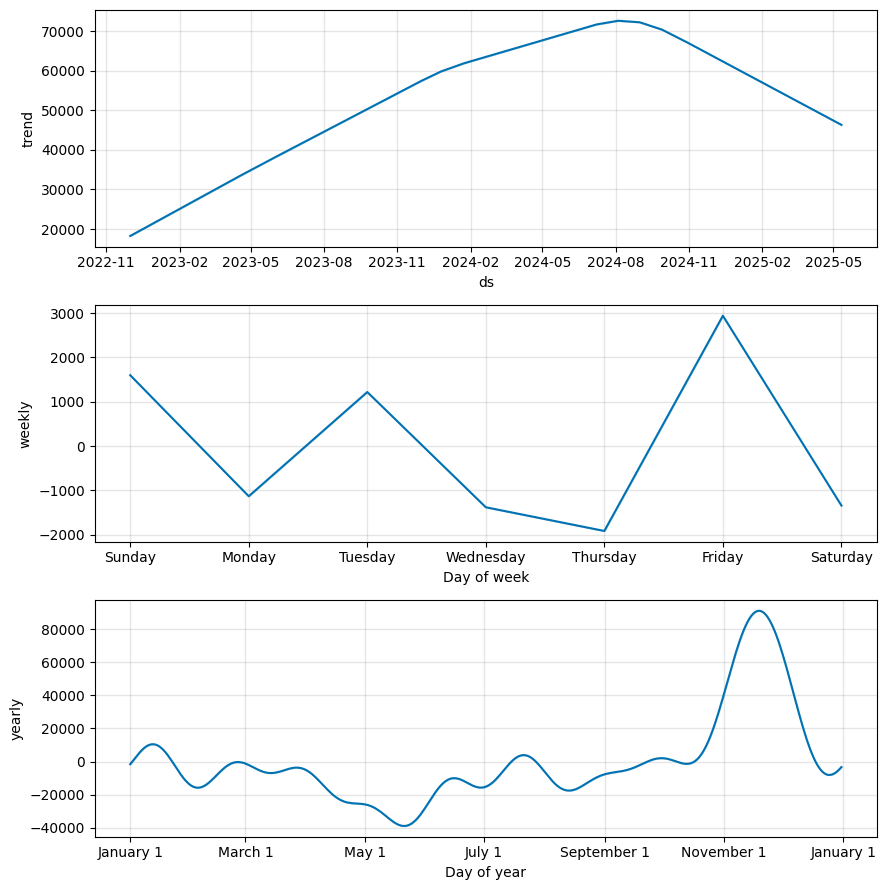

In [131]:
from prophet import Prophet

df_prophet = temp_sales.copy()
df_prophet.reset_index(inplace=True)
df_prophet = df_prophet[['Created at', 'Subtotal']].rename(columns={'Created at': 'ds', 'Subtotal': 'y'})

# Ensure 'ds' is in datetime format
df_prophet['ds'] = pd.to_datetime(df_prophet['ds']).dt.tz_localize(None)

model = Prophet()

model.fit(df_prophet)
future = model.make_future_dataframe(periods=3 , freq='W') 

# Make predictions
forecast = model.predict(future)

fig = model.plot(forecast)
fig2 = model.plot_components(forecast)

forecast




## Random Forest

Train RMSE: 4351.77217535809
Test RMSE: 5210.89110771849


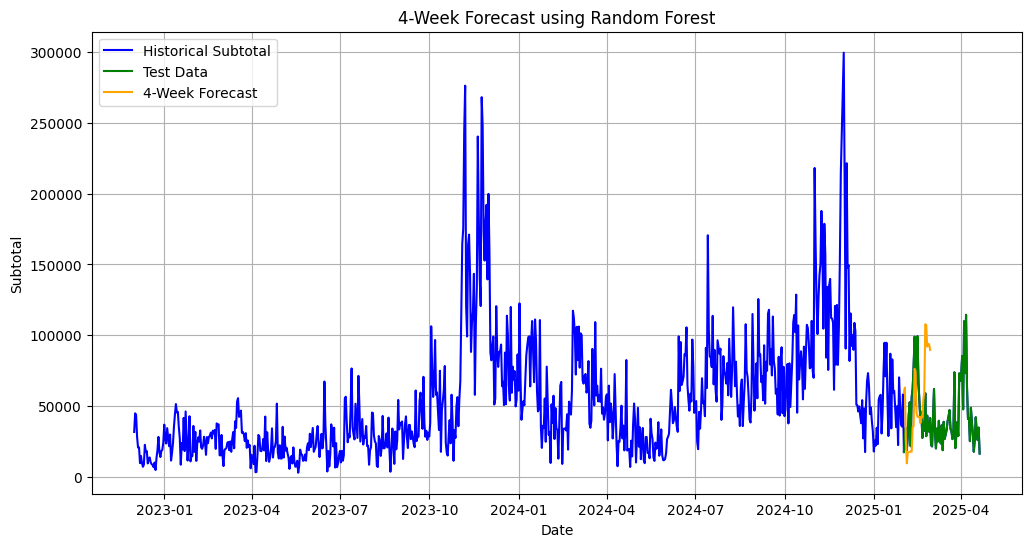

In [132]:
from sklearn.ensemble import RandomForestRegressor


# Train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("Train RMSE:", train_rmse)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test RMSE:", test_rmse)

# Forecast the next 4 weeks (28 days)
# Start with the last available data point
last_data = X_train.iloc[-1].values.reshape(1, -1)
predictions = []

for _ in range(28):  # Predict for the next 28 days
    # Scale the last data point
    last_data_scaled = scaler.transform(last_data)

    # Make prediction
    next_prediction = model.predict(last_data_scaled)[0]
    predictions.append(next_prediction)

    # Update lag features for the next prediction
    last_data = np.roll(last_data, shift=-1, axis=1)  # Shift features to the left
    last_data[0, -1] = next_prediction  # Add the new prediction to the last feature

# Create a DataFrame for the forecast
forecast_dates = pd.date_range(start=X_train.index[-1] + pd.Timedelta(days=1), periods=28)
forecast_df = pd.DataFrame(predictions, index=forecast_dates, columns=["Forecasted Subtotal"])

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(temp_sales.index, temp_sales["Subtotal"], label="Historical Subtotal", color="blue")
plt.plot(y_test.index, y_test, label="Test Data", color="green")
plt.plot(forecast_df.index, forecast_df["Forecasted Subtotal"], label="4-Week Forecast", color="orange")
plt.title("4-Week Forecast using Random Forest")
plt.xlabel("Date")
plt.ylabel("Subtotal")
plt.legend()
plt.grid()
plt.show()


## Prophet Model

In [133]:
# Weekly revenue
weekly_sales = temp_sales['Subtotal'].resample('W').sum()

# Monthly revenue
monthly_sales = temp_sales['Subtotal'].resample('M').sum()


### Prophet model weekely

00:29:01 - cmdstanpy - INFO - Chain [1] start processing
00:29:01 - cmdstanpy - INFO - Chain [1] done processing


            ds          yhat     yhat_lower    yhat_upper
125 2025-04-27  2.561515e+05   96874.500386  4.329143e+05
126 2025-05-04  2.637929e+05   98869.307286  4.259662e+05
127 2025-05-11  2.474056e+05   82140.696421  4.139897e+05
128 2025-05-18  2.015067e+05   35647.943478  3.592758e+05
129 2025-05-25  1.747139e+05    6471.270657  3.401375e+05
130 2025-06-01  2.151481e+05   57871.406183  3.802081e+05
131 2025-06-08  3.072315e+05  142836.340587  4.735606e+05
132 2025-06-15  3.803865e+05  208349.913252  5.559338e+05
133 2025-06-22  3.855147e+05  223159.865652  5.470658e+05
134 2025-06-29  3.503183e+05  180062.739040  5.203014e+05
135 2025-07-06  3.459002e+05  185027.230164  5.142086e+05
136 2025-07-13  4.021916e+05  228273.298995  5.588951e+05
137 2025-07-20  4.717720e+05  301297.644351  6.393161e+05
138 2025-07-27  4.844548e+05  327083.461532  6.589367e+05
139 2025-08-03  4.274625e+05  253853.762984  5.907709e+05
140 2025-08-10  3.578126e+05  191553.530641  5.267449e+05
141 2025-08-17

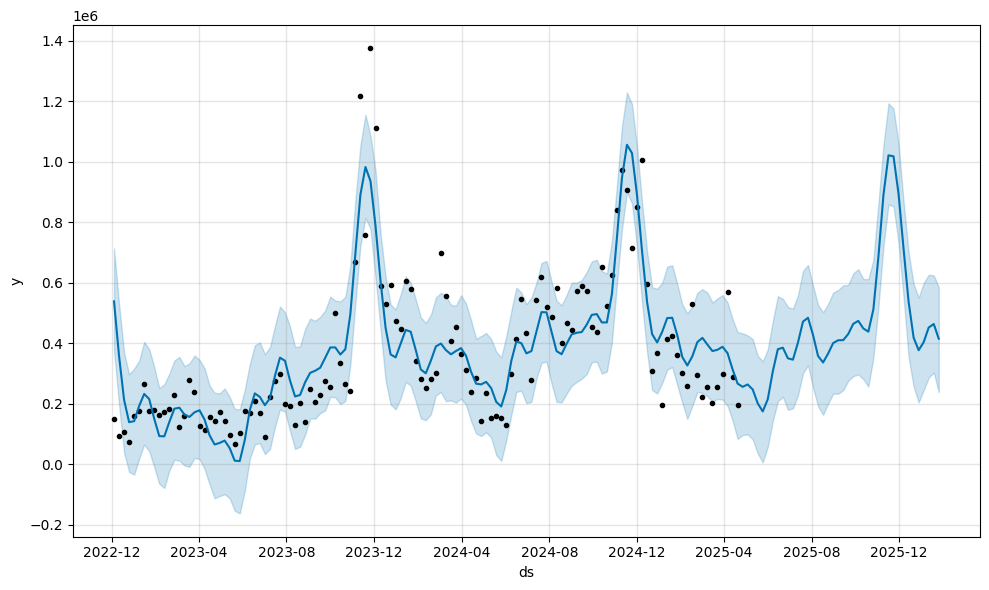

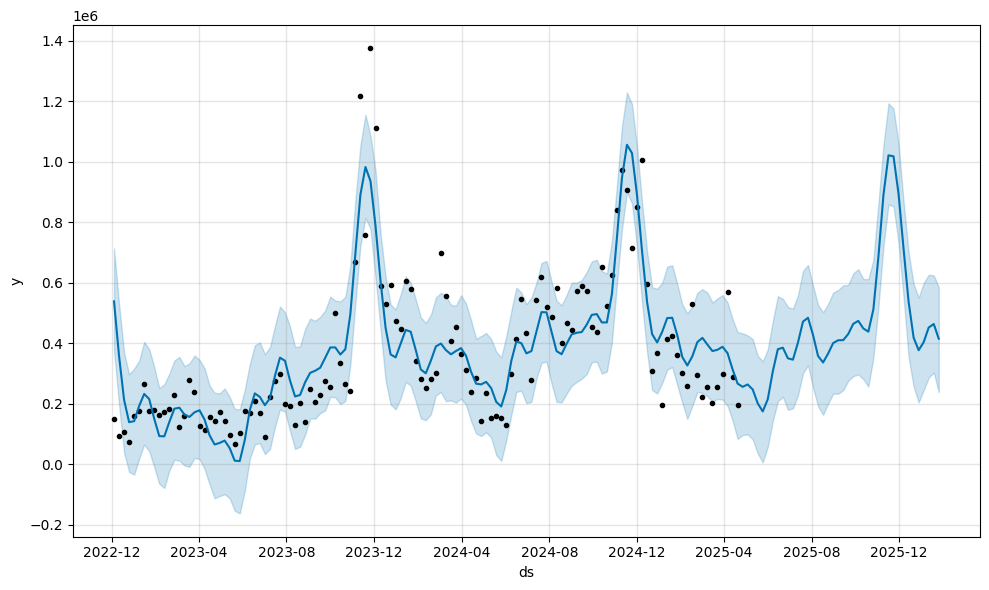

In [134]:
from prophet import Prophet

n_test = 40
# Prepare for Prophet
df_prophet = weekly_sales.reset_index()
df_prophet['Created at'] = df_prophet['Created at'].dt.tz_localize(None)
df_prophet.columns = ['ds', 'y']


train = df_prophet[:-n_test]
test = df_prophet[-n_test:]

# Fit model
model = Prophet()
model.fit(df_prophet)

# Future prediction
future = model.make_future_dataframe(periods=n_test, freq='W')  # predict 12 weeks ahead
forecast = model.predict(future)

forecast_test = forecast.tail(n_test)
print(forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

# Reset test index for merge
test = test.reset_index(drop=True)

# Merge
merged = test.copy()
merged['yhat'] = forecast_test['yhat'].values


rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
# Plot
model.plot(forecast)


### prophet Model Monthly

00:29:01 - cmdstanpy - INFO - Chain [1] start processing
00:29:01 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat    yhat_lower    yhat_upper
29 2025-05-31  1.191187e+06  7.142983e+05  1.680841e+06
30 2025-06-30  1.935913e+06  1.465467e+06  2.388368e+06
31 2025-07-31  2.331197e+06  1.861305e+06  2.786927e+06
RMSE: 908303.62
MAPE: 72.39%


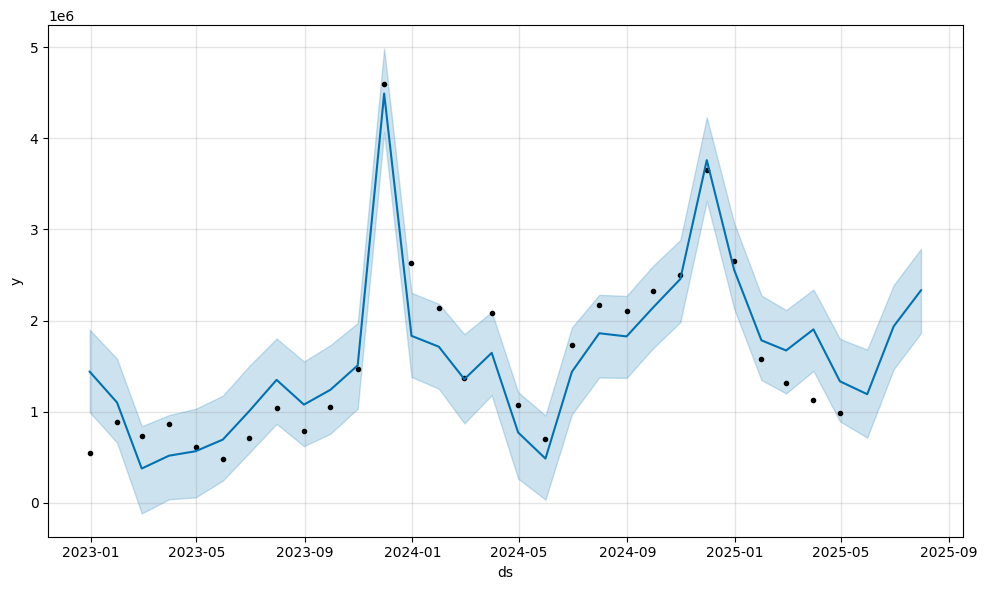

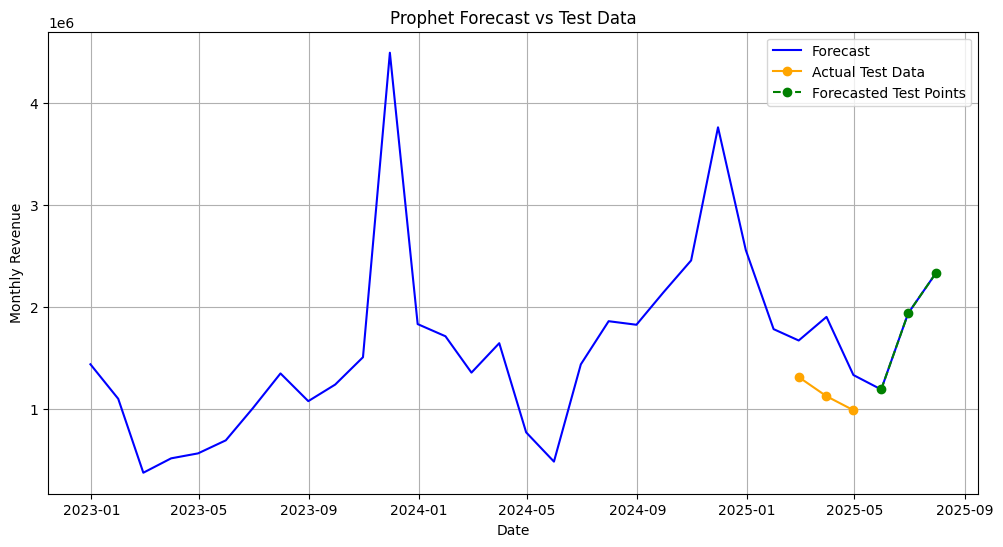

In [135]:
from prophet import Prophet

n_test = 3
# Prepare for Prophet
df_prophet = monthly_sales.reset_index()
df_prophet['Created at'] = df_prophet['Created at'].dt.tz_localize(None)
df_prophet.columns = ['ds', 'y']


train = df_prophet[:-n_test]
test = df_prophet[-n_test:]

# Fit model
model = Prophet()
model.fit(df_prophet)

# Future prediction
future = model.make_future_dataframe(periods=n_test, freq='M') 
forecast = model.predict(future)

forecast_test = forecast.tail(n_test)
print(forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

# Reset test index for merge
test = test.reset_index(drop=True)

# Merge
merged = test.copy()
merged['yhat'] = forecast_test['yhat'].values


rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
# Plot
model.plot(forecast)

# Plot the forecast vs test data
plt.figure(figsize=(12, 6))

# Plot the forecasted values
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='blue')

# Plot the actual test values
plt.plot(test['ds'], test['y'], label='Actual Test Data', color='orange', marker='o')

# Highlight the forecasted test data points
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecasted Test Points', color='green', marker='o', linestyle='dashed')

# Add labels, title, legend, and grid
plt.title('Prophet Forecast vs Test Data')
plt.xlabel('Date')
plt.ylabel('Monthly Revenue')
plt.legend()
plt.grid()
plt.show()


## SARIMAX

date
2022-12-04 00:00:00+02:00    148934.93
2022-12-11 00:00:00+02:00     92854.04
2022-12-18 00:00:00+02:00    106126.57
2022-12-25 00:00:00+02:00     72475.96
2023-01-01 00:00:00+02:00    159211.98
Freq: W-SUN, Name: sales, dtype: float64
ADF Statistic: -4.406650127079269
p-value: 0.0002888911879455811
Data is stationary.


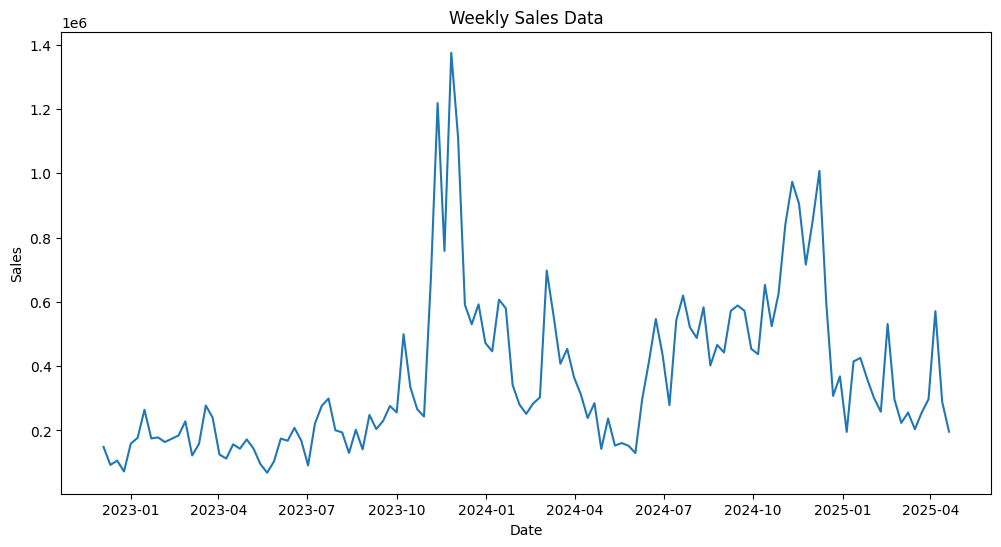

In [136]:

from statsmodels.tsa.stattools import adfuller

# Load your data
# Ensure your data has a 'date' column and a 'sales' column (or subtotal)
data = temp_sales.copy().reset_index()
data = data[['Created at','Subtotal']].rename(columns={'Created at': 'date', 'Subtotal': 'sales'})
data.set_index('date', inplace=True)

# Ensure the data is sorted by date
data = data.sort_index()


# Aggregate daily data into monthly data
# data_filtered.set_index('date', inplace=True)

weekly_data = data['sales'].resample('W').sum()  # Use .mean() if averaging is appropriate
print(weekly_data.head())

# # Train-Test Split
# # Use the last 12 months as the test set
# train_data = monthly_data.iloc[:-12]
# test_data = monthly_data.iloc[-12:]


# Check stationarity with Augmented Dickey-Fuller test
result = adfuller(data['sales'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] > 0.05:
    print("Data is non-stationary. Differencing might be required.")
else:
    print("Data is stationary.")

# Plot the sales data to visualize trends and seasonality
weekly_data = weekly_data.reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=weekly_data['date'], y=weekly_data['sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Weekly Sales Data')
plt.show()



                                       SARIMAX Results                                        
Dep. Variable:                                  sales   No. Observations:                  125
Model:             SARIMAX(1, 1, 0)x(0, 0, [1, 2], 7)   Log Likelihood               -1461.907
Date:                                Tue, 22 Apr 2025   AIC                           2931.814
Time:                                        00:29:02   BIC                           2942.580
Sample:                                             0   HQIC                          2936.180
                                                - 125                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1328      0.054     -2.451      0.014      -0.239      -0.027
ma.

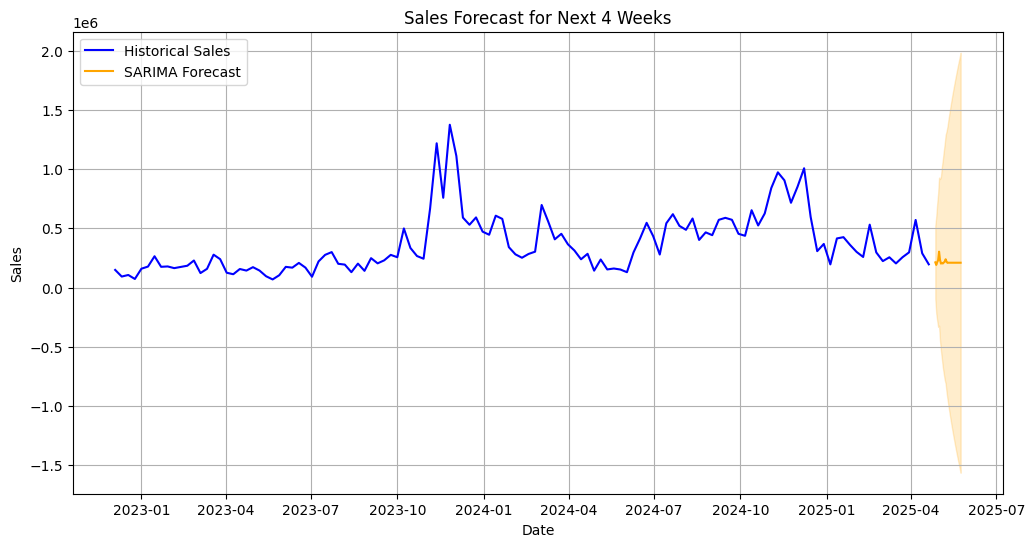

In [137]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p, d, q = 1, 1, 0 
P, D, Q, s = 0, 0, 2, 7  

model = SARIMAX(
    weekly_data['sales'],  
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = model.fit(disp=False)

# Print the model summary
print(sarima_fit.summary())

# Forecast the next 4 weeks (28 days in total)
forecast_steps = 28
forecast = sarima_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(weekly_data['date'].iloc[-1] + pd.Timedelta(days=7), periods=forecast_steps, freq='D')
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(weekly_data['date'], weekly_data['sales'], label='Historical Sales', color='blue')
plt.plot(forecast_index, forecast_mean, label='SARIMA Forecast', color='orange')
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='orange', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Forecast for Next 4 Weeks')
plt.legend()
plt.grid()
plt.show()

# Save the forecast to a CSV file
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'forecast': forecast_mean,
    'lower_ci': forecast_ci.iloc[:, 0],
    'upper_ci': forecast_ci.iloc[:, 1]
})

Text(0.5, 0, 'Month')

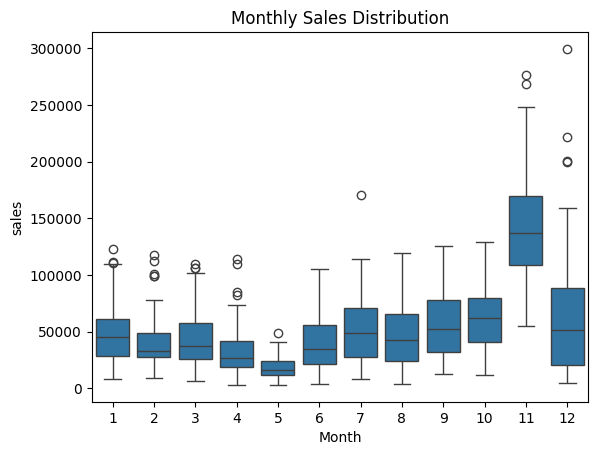

In [138]:
sns.boxplot(data=data, x=data.index.month, y='sales')
plt.title('Monthly Sales Distribution')
plt.xlabel('Month')

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
import itertools
import matplotlib.pyplot as plt

# Suppress warnings
warnings.filterwarnings("ignore")

# # Ensure the data is sorted by date
# data_filtered = data_filtered.sort_index()

# Train-Test Split
# Use the last 60 days as the test set
train_data = data.iloc[:-60]['Subtotal']
test_data = data.iloc[-60:]['Subtotal']

# Define the range of parameters for SARIMA
p = range(0, 3)  
d = range(0, 2)  
q = range(0, 3)  
P = range(0, 3)  
D = range(0, 2)  
Q = range(0, 3)  
s = [7]          

# Create a list of all possible parameter combinations
param_combinations = list(itertools.product(p, d, q, P, D, Q, s))

# Initialize variables to store the best model and its parameters
best_model = None
best_params = None
lowest_rmse = float('inf')

# Iterate through all parameter combinations
for params in param_combinations:
    try:
        # Unpack parameters
        p, d, q, P, D, Q, s = params
        
        # Define and fit the SARIMA model
        model = SARIMAX(
            train_data,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        model_fit = model.fit(disp=False)
        
        # Forecast for the test set
        forecast = model_fit.forecast(steps=len(test_data))
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        
        # Update the best model if the current one is better
        if rmse < lowest_rmse:
            best_model = model_fit
            best_params = params
            lowest_rmse = rmse

        # Print progress
        print(f"Tested parameters: {params}, RMSE: {rmse:.2f}")
    except Exception as e:
        print(f"Error with parameters: {params}, Error: {e}")
        continue

# Print the best parameters and RMSE
print(f"\nBest SARIMA Parameters: {best_params}, RMSE: {lowest_rmse:.2f}")

# Forecast the next 60 days using the best model
forecast_steps = 60
forecast = best_model.forecast(steps=forecast_steps)
forecast_index = pd.date_range(data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(data['sales'], label='Historical Sales')
plt.plot(forecast_index, forecast, label='SARIMA Forecast', color='orange')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Forecast for Next 60 Days')
plt.legend()
plt.show()

# Save the forecast to a CSV file
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'forecast': forecast
})
forecast_df.to_csv('sales_forecast_manual_grid_search.csv', index=False)

print("Forecast saved to 'sales_forecast_manual_grid_search.csv'")

## XGBOOST

In [140]:
reg = XGBRegressor(base_score=0.5, booster='gbtree',
                       colsampel_bytree=1,
                       subsample=0.8,    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.2,
                       reg_lambda=0.0,
                       reg_alpha=0.5,
                       dropout=0.2
                       )
reg.fit(X_train_scaled, y_train,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
        verbose=100)

[0]	validation_0-rmse:55636.18866	validation_1-rmse:39187.27602
[100]	validation_0-rmse:1941.07598	validation_1-rmse:4623.54827
[200]	validation_0-rmse:975.55553	validation_1-rmse:4351.30665
[265]	validation_0-rmse:678.36315	validation_1-rmse:4284.85454


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsampel_bytree=1, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, dropout=0.2,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, ...)

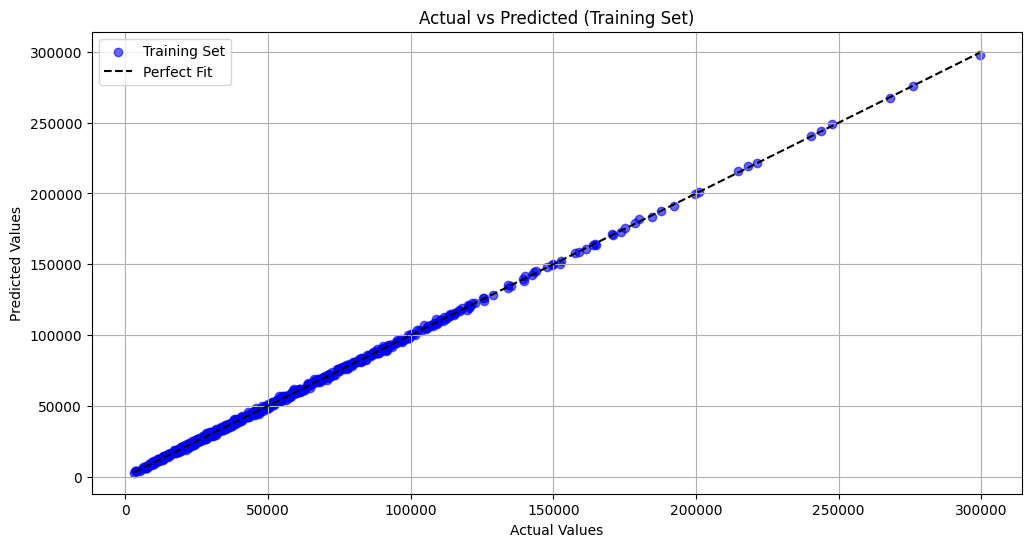

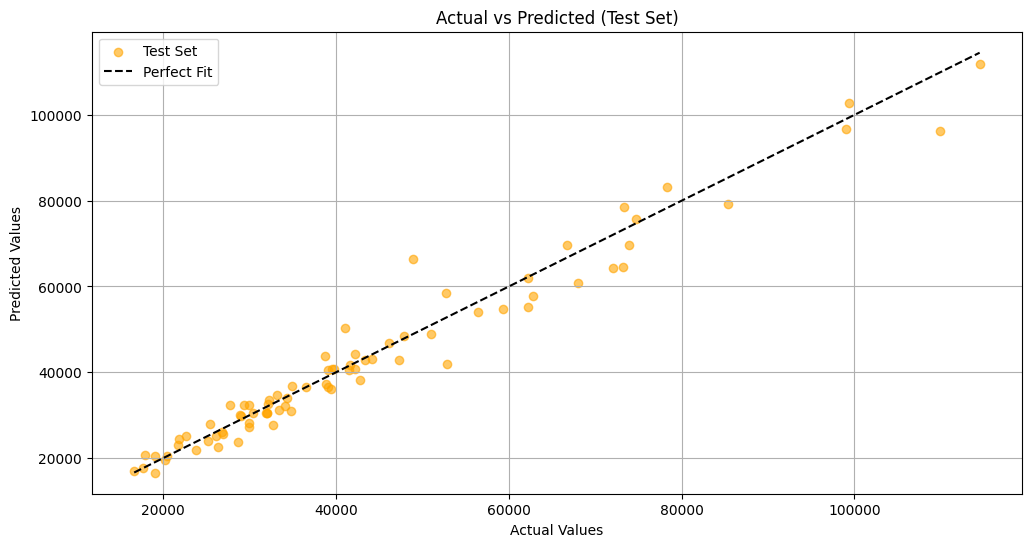

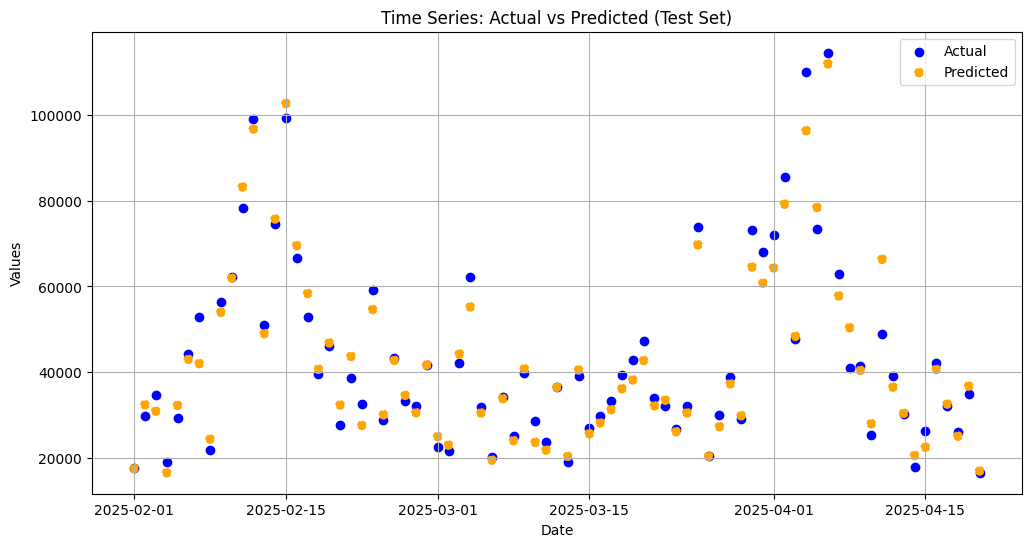

In [141]:

# Predictions for training and test sets
y_train_pred = reg.predict(X_train_scaled)
y_test_pred = reg.predict(X_test_scaled)

# Plot Actual vs Predicted for Training Set
plt.figure(figsize=(12, 6))
plt.scatter(y_train, y_train_pred, alpha=0.6, label='Training Set', color='blue')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='black', linestyle='--', label='Perfect Fit')
plt.title('Actual vs Predicted (Training Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()

# Plot Actual vs Predicted for Test Set
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, label='Test Set', color='orange')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', label='Perfect Fit')
plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()

# Time Series Plot of Actual vs Predicted (Test Set)
plt.figure(figsize=(12, 6))
plt.scatter(y_test.index, y_test, label='Actual', color='blue')
plt.scatter(y_test.index, y_test_pred, label='Predicted', color='orange', linestyle='--')
plt.title('Time Series: Actual vs Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.show()

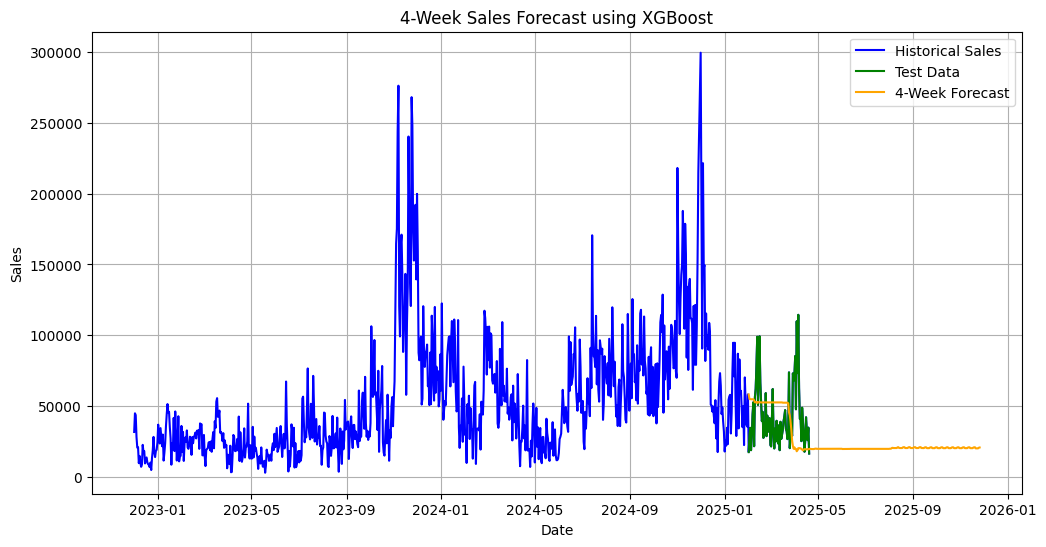

In [142]:
# Forecast the next 4 weeks (28 days)
last_data = X_train.iloc[-1].copy()  # Start with the last row of the training data
future_predictions = []
forecast_dates = []

for i in range(1, 300):  # Forecast for the next 28 days
    forecast_date = X_train.index[-1] + pd.Timedelta(days=i)
    forecast_dates.append(forecast_date)

    # Update lag features using previous predictions
    last_data["total_prev_day"] = future_predictions[-1] if future_predictions else last_data["total_prev_day"]
    last_data["total_prev_week"] = future_predictions[-7] if len(future_predictions) >= 7 else last_data["total_prev_week"]
    last_data["total_same_day_last_week"] = future_predictions[-7] if len(future_predictions) >= 7 else last_data["total_same_day_last_week"]

    # Update rolling statistics
    if future_predictions:
        last_7d = future_predictions[-7:] if len(future_predictions) >= 7 else future_predictions
        last_30d = future_predictions[-30:] if len(future_predictions) >= 30 else future_predictions
        last_data["total_7d_avg"] = np.mean(last_7d)
        last_data["total_30d_avg"] = np.mean(last_30d)
        last_data["total_7d_std"] = np.std(last_7d)

    # Update growth features
    if len(future_predictions) >= 1:
        last_data["total_growth_1d"] = ((future_predictions[-1] - future_predictions[-2]) / future_predictions[-2]) if len(future_predictions) >= 2 else 0
    if len(future_predictions) >= 7:
        last_data["total_growth_1w"] = ((future_predictions[-1] - future_predictions[-7]) / future_predictions[-7]) if len(future_predictions) >= 7 else 0

    # Update time-based features
    last_data["day_of_year"] = forecast_date.day_of_year
    last_data["week_of_year"] = forecast_date.isocalendar()[1]
    last_data["week_sin"] = np.sin(2 * np.pi * last_data["week_of_year"] / 52)
    last_data["week_cos"] = np.cos(2 * np.pi * last_data["week_of_year"] / 52)

    # Business-specific features (assumed constant for now; replace with dynamic logic if needed)
    last_data["discount_ratio"] = last_data["discount_ratio"]
    last_data["avg_shipping_cost"] = last_data["avg_shipping_cost"]
    last_data["avg_items_per_order"] = last_data["avg_items_per_order"]

    # Ensure the feature order matches the training data
    last_data = last_data[X.columns]
    last_data_scaled = scaler.transform([last_data.values])

    # Make prediction
    next_prediction = reg.predict(last_data_scaled)[0]
    future_predictions.append(next_prediction)

# Create a DataFrame for forecasted values
forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "forecast": future_predictions
})
forecast_df.set_index("date", inplace=True)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(temp_sales.index, temp_sales["Subtotal"], label="Historical Sales", color="blue")
plt.plot(y_test.index, y_test, label="Test Data", color="green")
plt.plot(forecast_df.index, forecast_df["forecast"], label="4-Week Forecast", color="orange")
plt.title("4-Week Sales Forecast using XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

### XGB BOOST GridSearch


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the model
reg = XGBRegressor(objective='reg:squarederror', n_estimators=1000)

# Define the parameter grid
param_grid = {
    'base_score': [0.5, 0.7, 0.9],
    'booster': ['gbtree', 'gblinear'],
    'learning_rate': [0.001,0.01, 0.1, 0.2],
    'n_estimators': [100,200, 500,800, 1000],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.0, 0.5, 1.0],
    'reg_lambda': [0.0, 0.5, 1.0]
}

# Set up the grid search
grid_search = GridSearchCV(estimator=reg, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', 
                           cv=3, verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)
# Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
# Best Parameters: {'base_score': 0.5, 'booster': 'gbtree', 'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 1000, 'reg_alpha': 0.5, 'reg_lambda': 0.0, 'subsample': 0.8}
# Best Score: -109034490.68362711